# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# muat dataset dari file CSV
df = pd.read_csv('sleep_efficiency_raw.csv')
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
df.head()

Jumlah baris: 452, Jumlah kolom: 15


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


In [ ]:
# cek struktur data dan tipe kolomnya
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    object 
 3   Bedtime                 452 non-null    object 
 4   Wakeup time             452 non-null    object 
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null    object 
 14  Exercise frequency      446 non-null    fl

In [ ]:
# cek beberapa baris terakhir juga
df.tail()

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
447,448,27,Female,2021-11-13 22:00:00,2021-11-13 05:30:00,7.5,0.91,22,57,21,0.0,0.0,0.0,No,5.0
448,449,52,Male,2021-03-31 21:00:00,2021-03-31 03:00:00,6.0,0.74,28,57,15,4.0,25.0,0.0,No,3.0
449,450,40,Female,2021-09-07 23:00:00,2021-09-07 07:30:00,8.5,0.55,20,32,48,1.0,NaN,3.0,Yes,0.0
450,451,45,Male,2021-07-29 21:00:00,2021-07-29 04:00:00,7.0,0.76,18,72,10,3.0,0.0,0.0,No,3.0
451,452,18,Male,2021-03-17 02:30:00,2021-03-17 10:00:00,7.5,0.63,22,23,55,1.0,50.0,0.0,No,1.0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
# statistik deskriptif buat dapet gambaran umum data
df.describe()

,ID,Age,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Exercise frequency
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,438.000000,446.000000
mean,226.500000,40.285398,7.465708,0.788916,22.615044,52.823009,24.561947,1.641204,23.653396,1.173516,1.791480
std,130.625419,13.172250,0.866625,0.135237,3.525963,15.654235,15.313665,1.356762,30.202785,1.621377,1.428134
min,1.000000,9.000000,5.000000,0.500000,15.000000,18.000000,7.000000,0.000000,0.000000,0.000000,0.000000
25%,113.750000,29.000000,7.000000,0.697500,20.000000,48.250000,15.000000,1.000000,0.000000,0.000000,0.000000
50%,226.500000,40.000000,7.500000,0.820000,22.000000,58.000000,18.000000,1.000000,25.000000,0.000000,2.000000
75%,339.250000,52.000000,8.000000,0.900000,25.000000,63.000000,32.500000,3.000000,50.000000,2.000000,3.000000
max,452.000000,69.000000,10.000000,0.990000,30.000000,75.000000,63.000000,4.000000,200.000000,5.000000,5.000000


In [ ]:
# cek missing values per kolom
missing = df.isnull().sum()
print("Missing values per kolom:")
print(missing[missing > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per kolom:
Awakenings              20
Caffeine consumption    25
Alcohol consumption     14
Exercise frequency       6
dtype: int64

Total missing values: 65


In [ ]:
# cek duplikat
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 0


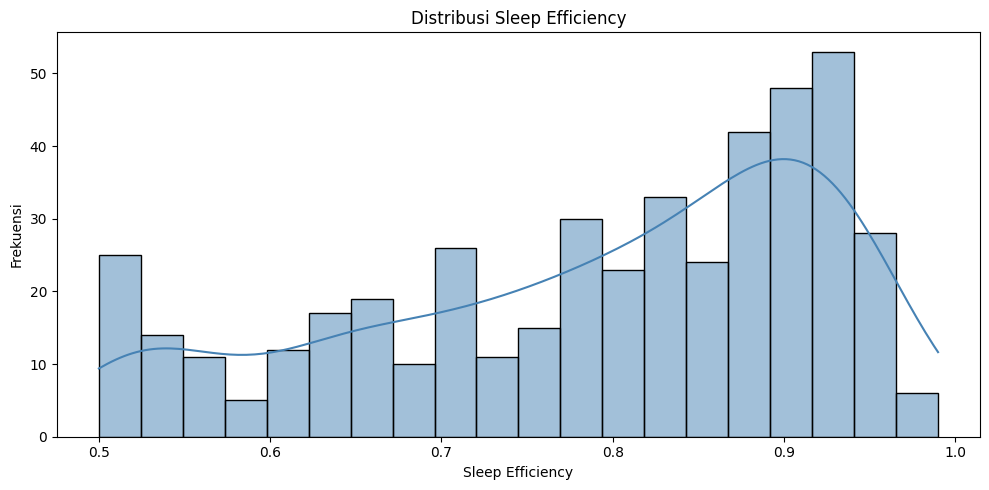

In [ ]:
# distribusi target (Sleep efficiency)
plt.figure(figsize=(10, 5))
sns.histplot(df['Sleep efficiency'], bins=20, kde=True, color='steelblue')
plt.title('Distribusi Sleep Efficiency')
plt.xlabel('Sleep Efficiency')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

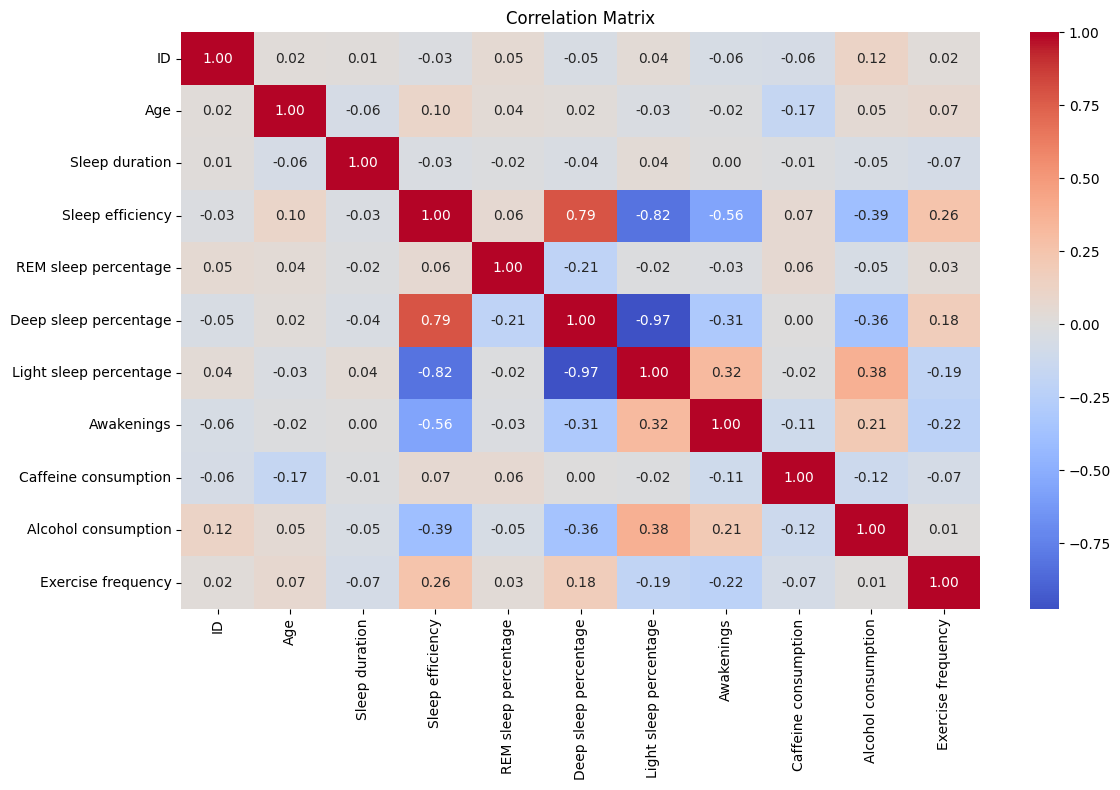

In [ ]:
# heatmap korelasi antar fitur numerik
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

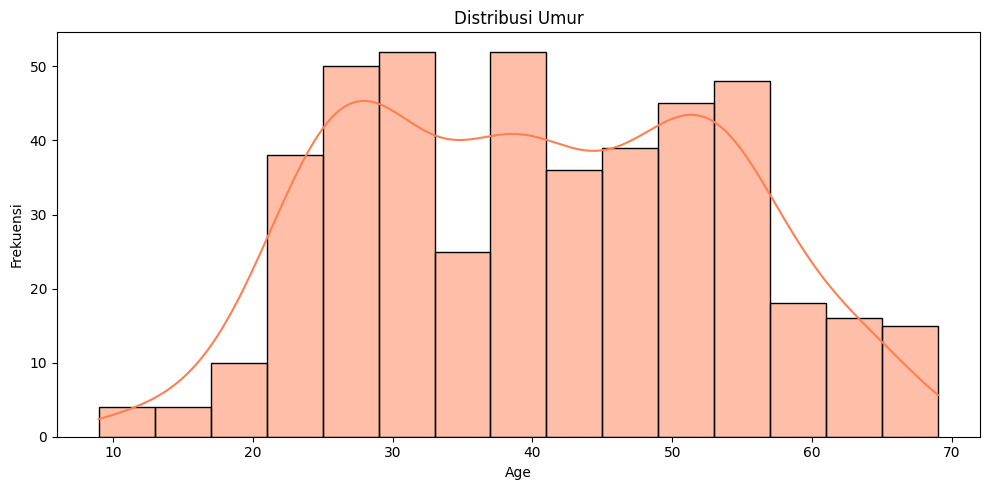

In [ ]:
# distribusi umur responden
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=15, kde=True, color='coral')
plt.title('Distribusi Umur')
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

C:\Users\Rnov24\AppData\Local\Temp\ipykernel_10188\1458851141.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='Set2')


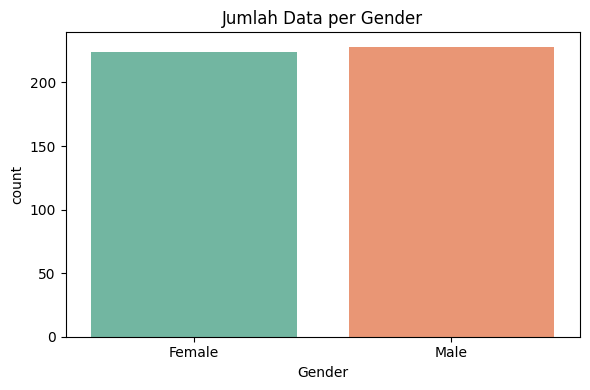

In [ ]:
# perbandingan gender
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Jumlah Data per Gender')
plt.tight_layout()
plt.show()

C:\Users\Rnov24\AppData\Local\Temp\ipykernel_10188\1301948208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Smoking status', y='Sleep efficiency', data=df, palette='Set3')


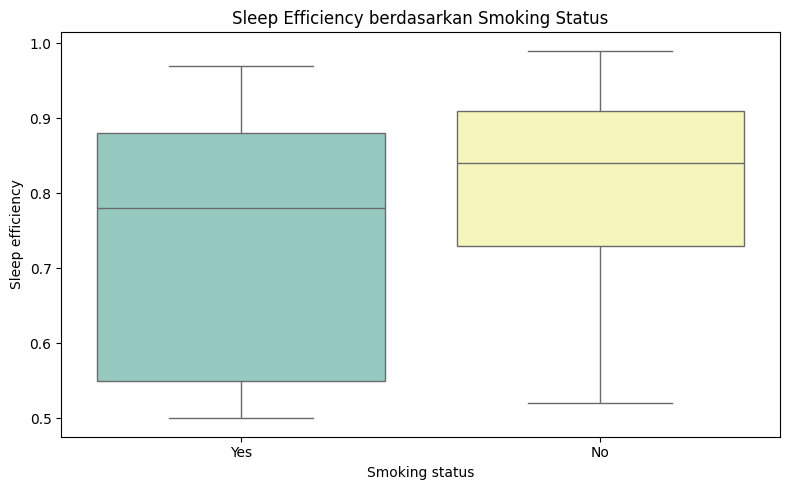

In [ ]:
# pengaruh smoking terhadap sleep efficiency
plt.figure(figsize=(8, 5))
sns.boxplot(x='Smoking status', y='Sleep efficiency', data=df, palette='Set3')
plt.title('Sleep Efficiency berdasarkan Smoking Status')
plt.tight_layout()
plt.show()

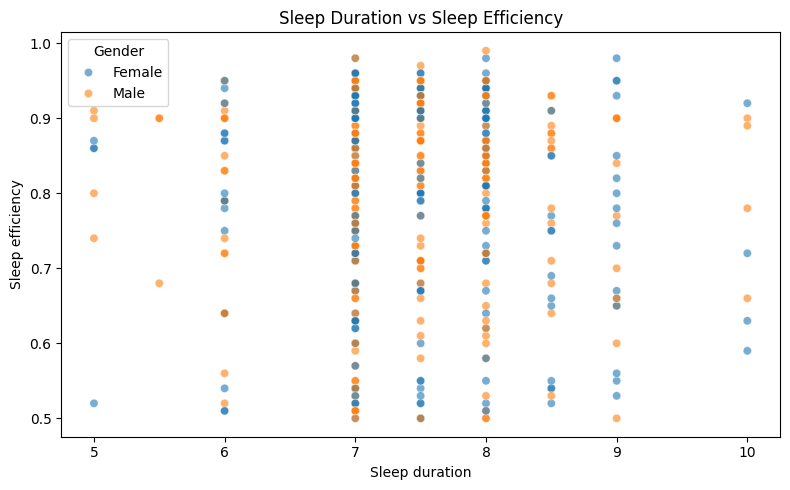

In [ ]:
# scatter plot sleep duration vs sleep efficiency
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Sleep duration', y='Sleep efficiency', hue='Gender', data=df, alpha=0.6)
plt.title('Sleep Duration vs Sleep Efficiency')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# ===== PERSIAPAN =====
# buat copy dataframe biar data asli tetep aman
df_clean = df.copy()

# buang kolom yang nggak relevan buat modelling
# ID cuma identifier, Bedtime dan Wakeup time formatnya datetime string, ribet dan nggak terlalu berguna
cols_to_drop = ['ID', 'Bedtime', 'Wakeup time']
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"Kolom yang dibuang: {cols_to_drop}")
print(f"Sisa kolom ({len(df_clean.columns)}): {list(df_clean.columns)}")
print(f"Shape: {df_clean.shape}")

Kolom yang dibuang: ['ID', 'Bedtime', 'Wakeup time']
Sisa kolom (12): ['Age', 'Gender', 'Sleep duration', 'Sleep efficiency', 'REM sleep percentage', 'Deep sleep percentage', 'Light sleep percentage', 'Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Smoking status', 'Exercise frequency']
Shape: (452, 12)


Kondisi missing values saat ini:
---------------------------------------------
  Awakenings                     ->  20 missing (4.4%)
  Caffeine consumption           ->  25 missing (5.5%)
  Alcohol consumption            ->  14 missing (3.1%)
  Exercise frequency             ->   6 missing (1.3%)

Total sel kosong: 65


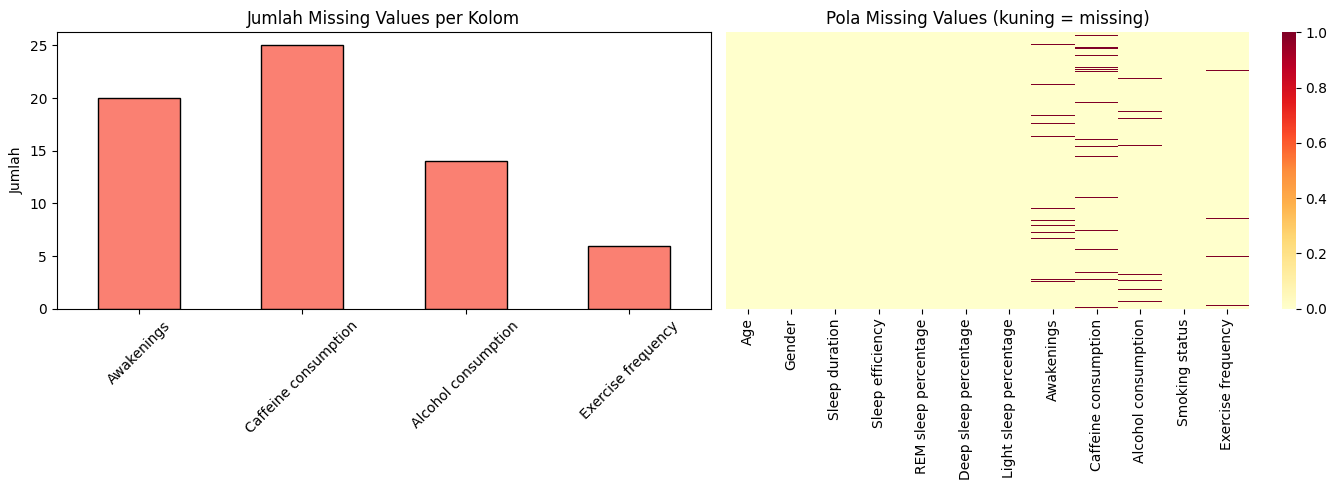

In [ ]:
# ===== STEP 1: Menangani Data Kosong (Missing Values) =====

# lihat kondisi missing values sebelum ditangani
missing_before = df_clean.isnull().sum()
missing_cols = missing_before[missing_before > 0]

print("Kondisi missing values saat ini:")
print("-" * 45)
for col, count in missing_cols.items():
    pct = (count / len(df_clean)) * 100
    print(f"  {col:30s} -> {count:3d} missing ({pct:.1f}%)")
print(f"\nTotal sel kosong: {df_clean.isnull().sum().sum()}")

# visualisasi missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart missing values
missing_cols.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Jumlah Missing Values per Kolom')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=45)

# heatmap missing values
sns.heatmap(df_clean.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Pola Missing Values (kuning = missing)')

plt.tight_layout()
plt.show()

In [ ]:
# isi missing values
# strategi: pake median buat numerik (lebih robust terhadap outlier daripada mean)
for col in df_clean.columns:
    null_count = df_clean[col].isnull().sum()
    if null_count > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
            print(f"[MEDIAN] '{col}' -> {null_count} missing diisi dengan {median_val}")
        else:
            mode_val = df_clean[col].mode()[0]
            df_clean[col] = df_clean[col].fillna(mode_val)
            print(f"[MODE]   '{col}' -> {null_count} missing diisi dengan '{mode_val}'")

print(f"\nSisa missing values: {df_clean.isnull().sum().sum()} (harusnya 0)")

[MEDIAN] 'Awakenings' -> 20 missing diisi dengan 1.0
[MEDIAN] 'Caffeine consumption' -> 25 missing diisi dengan 25.0
[MEDIAN] 'Alcohol consumption' -> 14 missing diisi dengan 0.0
[MEDIAN] 'Exercise frequency' -> 6 missing diisi dengan 2.0

Sisa missing values: 0 (harusnya 0)


In [ ]:
# ===== STEP 2: Menghapus Data Duplikat =====

n_before = len(df_clean)
duplicates = df_clean.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")

if duplicates > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    n_after = len(df_clean)
    print(f"Baris sebelum: {n_before} -> sesudah: {n_after} ({n_before - n_after} baris dibuang)")
else:
    print("Data bersih, nggak ada duplikat.")

print(f"Shape sekarang: {df_clean.shape}")

Jumlah baris duplikat: 0
Data bersih, nggak ada duplikat.
Shape sekarang: (452, 12)


In [ ]:
# ===== STEP 4: Deteksi dan Penanganan Outlier =====
# (dilakuin sebelum encoding/standarisasi biar hasilnya lebih akurat)

# deteksi outlier pake IQR method
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper, ((series < lower) | (series > upper)).sum()

num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Deteksi outlier (IQR method):")
print("-" * 60)
outlier_info = {}
for col in num_cols:
    lower, upper, n_out = detect_outliers_iqr(df_clean[col])
    if n_out > 0:
        outlier_info[col] = (lower, upper, n_out)
        print(f"  {col:30s} -> {n_out:3d} outliers (range valid: {lower:.2f} - {upper:.2f})")

if not outlier_info:
    print("  Nggak ada outlier yang terdeteksi.")

Deteksi outlier (IQR method):
------------------------------------------------------------
  Sleep duration                 ->  16 outliers (range valid: 5.50 - 9.50)
  Deep sleep percentage          ->  60 outliers (range valid: 26.12 - 85.12)
  Light sleep percentage         ->   2 outliers (range valid: -11.25 - 58.75)
  Caffeine consumption           ->   4 outliers (range valid: -75.00 - 125.00)


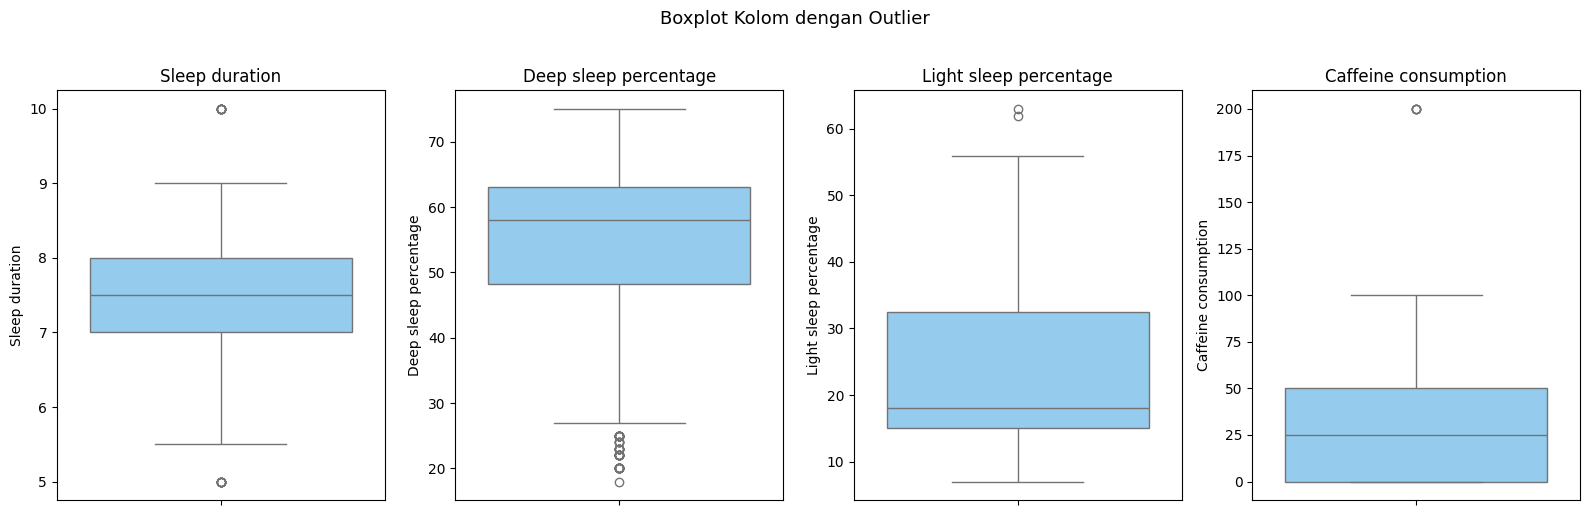

In [ ]:
# visualisasi outlier pake boxplot
outlier_cols = list(outlier_info.keys()) if outlier_info else num_cols[:6]
n_plots = len(outlier_cols)

if n_plots > 0:
    fig, axes = plt.subplots(1, min(n_plots, 4), figsize=(4 * min(n_plots, 4), 5))
    if n_plots == 1:
        axes = [axes]

    for i, col in enumerate(outlier_cols[:4]):
        sns.boxplot(y=df_clean[col], ax=axes[i], color='lightskyblue')
        axes[i].set_title(f'{col}')

    plt.suptitle('Boxplot Kolom dengan Outlier', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# capping outlier pake batas IQR (winsorizing)
# daripada dibuang, kita clip nilainya ke batas atas/bawah biar nggak kehilangan data
for col, (lower, upper, n_out) in outlier_info.items():
    before_min = df_clean[col].min()
    before_max = df_clean[col].max()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"  {col}: range ({before_min:.2f}, {before_max:.2f}) -> ({df_clean[col].min():.2f}, {df_clean[col].max():.2f})")

print("\nOutlier udah di-cap ke batas IQR.")

  Sleep duration: range (5.00, 10.00) -> (5.50, 9.50)
  Deep sleep percentage: range (18.00, 75.00) -> (26.12, 75.00)
  Light sleep percentage: range (7.00, 63.00) -> (7.00, 58.75)
  Caffeine consumption: range (0.00, 200.00) -> (0.00, 125.00)

Outlier udah di-cap ke batas IQR.


In [ ]:
# ===== STEP 5: Encoding Data Kategorikal =====

# kolom kategorikal yang perlu di-encode
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom kategorikal: {cat_cols}")

# tampilkan unique values sebelum encoding
for col in cat_cols:
    print(f"\n  {col}: {df_clean[col].unique()} ({df_clean[col].nunique()} unique)")

Kolom kategorikal: ['Gender', 'Smoking status']

  Gender: ['Female' 'Male'] (2 unique)

  Smoking status: ['Yes' 'No'] (2 unique)


In [ ]:
# pake LabelEncoder karena semua kolom kategorikal cuma punya 2 nilai (binary)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col}: {mapping}")

print(f"\nSemua kolom kategorikal udah di-encode ke numerik.")
df_clean.dtypes

  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Smoking status: {'No': np.int64(0), 'Yes': np.int64(1)}

Semua kolom kategorikal udah di-encode ke numerik.


Age                         int64
Gender                      int64
Sleep duration            float64
Sleep efficiency          float64
REM sleep percentage        int64
Deep sleep percentage     float64
Light sleep percentage    float64
Awakenings                float64
Caffeine consumption      float64
Alcohol consumption       float64
Smoking status              int64
Exercise frequency        float64
dtype: object

Distribusi kelompok umur:
Age_group
Anak             9
Dewasa_Muda    157
Dewasa         212
Lansia          74
Name: count, dtype: int64


C:\Users\Rnov24\AppData\Local\Temp\ipykernel_10188\1291254470.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age_group', y='Sleep efficiency', data=df_clean, palette='viridis',


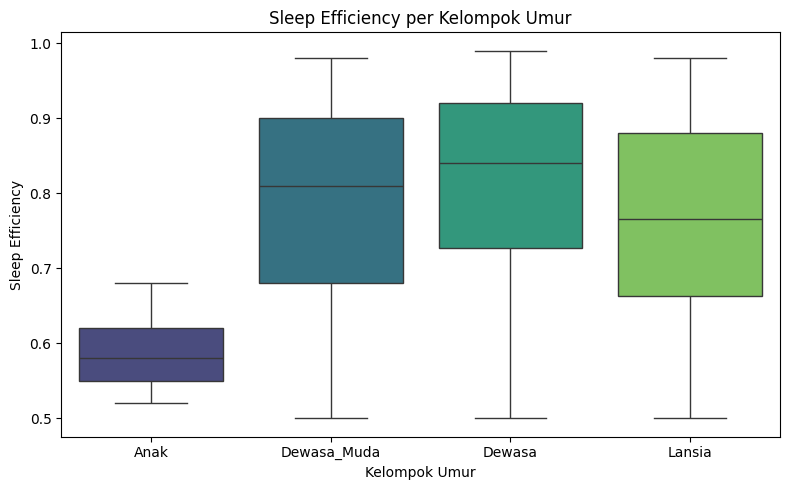

In [ ]:
# ===== STEP 6: Binning (Pengelompokan Data) =====

# bikin kategori umur buat analisis tambahan
# bins: Anak (<18), Dewasa Muda (18-35), Dewasa (36-55), Lansia (>55)
age_bins = [0, 18, 35, 55, 100]
age_labels = ['Anak', 'Dewasa_Muda', 'Dewasa', 'Lansia']

# binning berdasarkan nilai asli (sebelum standarisasi)
# kita pake kolom Age di dataframe original buat referensi
df_clean['Age_group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# lihat distribusi per group
print("Distribusi kelompok umur:")
print(df_clean['Age_group'].value_counts().sort_index())

# visualisasi sleep efficiency per age group
plt.figure(figsize=(8, 5))
sns.boxplot(x='Age_group', y='Sleep efficiency', data=df_clean, palette='viridis',
            order=age_labels)
plt.title('Sleep Efficiency per Kelompok Umur')
plt.xlabel('Kelompok Umur')
plt.ylabel('Sleep Efficiency')
plt.tight_layout()
plt.show()

In [ ]:
# encode age group ke numerik juga, terus drop kolom category-nya
le_age = LabelEncoder()
df_clean['Age_group'] = le_age.fit_transform(df_clean['Age_group'])
print(f"Age group mapping: {dict(zip(le_age.classes_, le_age.transform(le_age.classes_)))}")

Age group mapping: {'Anak': np.int64(0), 'Dewasa': np.int64(1), 'Dewasa_Muda': np.int64(2), 'Lansia': np.int64(3)}


In [ ]:
# ===== STEP 3: Normalisasi / Standarisasi Fitur =====
# dilakuin terakhir setelah encoding dan binning biar semua fitur numerik ikut ke-scale

target_col = 'Sleep efficiency'
feature_cols = [col for col in df_clean.select_dtypes(include=[np.number]).columns if col != target_col]

print(f"Fitur yang bakal distandarisasi ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  {col}: mean={df_clean[col].mean():.3f}, std={df_clean[col].std():.3f}")

scaler = StandardScaler()
df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])

print(f"\nSetelah standarisasi:")
for col in feature_cols[:3]:
    print(f"  {col}: mean={df_clean[col].mean():.6f}, std={df_clean[col].std():.6f}")
print("  ...")

Fitur yang bakal distandarisasi (12):
  Age: mean=40.285, std=13.172
  Gender: mean=0.504, std=0.501
  Sleep duration: mean=7.466, std=0.819
  REM sleep percentage: mean=22.615, std=3.526
  Deep sleep percentage: mean=53.311, std=14.709
  Light sleep percentage: mean=24.545, std=15.274
  Awakenings: mean=1.613, std=1.333
  Caffeine consumption: mean=23.064, std=26.013
  Alcohol consumption: mean=1.137, std=1.609
  Smoking status: mean=0.341, std=0.474
  Exercise frequency: mean=1.794, std=1.419
  Age_group: mean=1.655, std=0.771

Setelah standarisasi:
  Age: mean=-0.000000, std=1.001108
  Gender: mean=-0.000000, std=1.001108
  Sleep duration: mean=-0.000000, std=1.001108
  ...


In [ ]:
# ===== RINGKASAN PREPROCESSING =====

print("=" * 50)
print("RINGKASAN PREPROCESSING")
print("=" * 50)
print(f"Baris awal       : {len(df)}")
print(f"Baris akhir       : {len(df_clean)}")
print(f"Kolom awal        : {len(df.columns)}")
print(f"Kolom akhir       : {len(df_clean.columns)}")
print(f"Missing values    : 0")
print(f"Duplikat          : 0")
print(f"Target kolom      : {target_col}")
print(f"Fitur kolom       : {len(feature_cols)}")
print("-" * 50)
print(f"Kolom final: {list(df_clean.columns)}")

df_clean.head()

RINGKASAN PREPROCESSING
Baris awal       : 452
Baris akhir       : 452
Kolom awal        : 15
Kolom akhir       : 13
Missing values    : 0
Duplikat          : 0
Target kolom      : Sleep efficiency
Fitur kolom       : 12
--------------------------------------------------
Kolom final: ['Age', 'Gender', 'Sleep duration', 'Sleep efficiency', 'REM sleep percentage', 'Deep sleep percentage', 'Light sleep percentage', 'Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Smoking status', 'Exercise frequency', 'Age_group']


,Age,Gender,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency,Age_group
0,1.878342,-1.008889,-1.791007,0.88,-1.310325,1.135884,-0.822242,-1.211366,-0.887622,-0.707565,1.391066,0.850779,1.746377
1,2.182347,0.991189,-0.569067,0.66,-1.026401,-1.722685,1.864961,1.041875,-0.887622,1.159085,1.391066,0.850779,1.746377
2,-0.021691,-1.008889,0.652873,0.89,-0.742476,1.135884,-0.953325,-0.460286,-0.887622,-0.707565,-0.718873,0.850779,-0.850210
3,-0.021691,-1.008889,-1.791007,0.51,0.109298,-1.850300,1.799419,1.041875,1.036623,2.403518,1.391066,-0.560421,-0.850210
4,1.270331,0.991189,0.652873,0.76,1.244997,0.114966,-0.428993,1.041875,-0.887622,1.159085,-0.718873,0.850779,1.746377


In [ ]:
# simpan dataset yang udah clean ke CSV
output_path = 'preprocessing/sleep_efficiency_preprocessing.csv'
df_clean.to_csv(output_path, index=False)
print(f"Dataset preprocessing disimpan ke: {output_path}")
print(f"Ukuran akhir: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")
print("Siap dipake buat training model!")

Dataset preprocessing disimpan ke: preprocessing/sleep_efficiency_preprocessing.csv
Ukuran akhir: 452 baris, 13 kolom
Siap dipake buat training model!
